# **Tweet Sentiment Analysis Project**

This project focuses on analyzing the sentiment of tweets using natural language processing (NLP) techniques.  
The goal is to classify each tweet as **positive**, **neutral**, or **negative** based on its textual content.

### **📦 Dataset**

We use the [Sentiment140 dataset](https://www.kaggle.com/datasets/kazanova/sentiment140), which contains **1.6 million tweets** labeled with sentiment polarity:
- `0` → Negative  
- `2` → Neutral  
- `4` → Positive  

The dataset includes tweet text along with other metadata such as user info and timestamps.  
For this project, only the tweet text and sentiment label columns are used.

In [44]:
# Install required packages
%pip install numpy pandas matplotlib seaborn scikit-learn --quiet

import pandas as pd # 2.2.3
import numpy as np # 2.0.2
import matplotlib.pyplot as plt
import seaborn as sns

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [45]:
# file path
file_path = "training.1600000.processed.noemoticon.csv"

# Read the CSV dataset
df = pd.read_csv(file_path, encoding='latin1', header=None, names=['sentiment', 'id', 'date', 'query', 'user', 'text'])

# Display the first 5 rows of the dataset
df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## **🧐 Data Analysis**

In [46]:
# list unique queries in the dataset
unique_queries = df['query'].unique()
print(unique_queries)

['NO_QUERY']


In [47]:
# drop the query column since it contains only one value (NO_QUERY)
df = df.drop('query', axis=1)
df = df.drop('date', axis=1)
df = df.drop('id', axis=1)

df.head()

,sentiment,user,text
0,0,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,scotthamilton,is upset that he can't update his Facebook by ...
2,0,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,ElleCTF,my whole body feels itchy and like its on fire
4,0,Karoli,"@nationwideclass no, it's not behaving at all...."


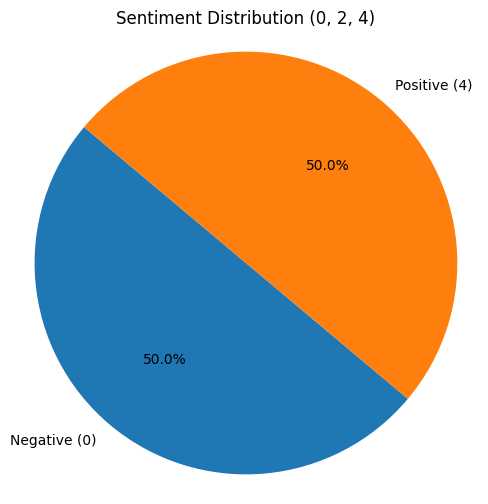

In [48]:
import matplotlib.pyplot as plt

filtered = df[df['sentiment'].isin([0, 2, 4])]
sentiment_counts = filtered['sentiment'].value_counts().sort_index()

label_map = {0: 'Negative (0)', 2: 'Neutral (2)', 4: 'Positive (4)'}
labels = [label_map[s] for s in sentiment_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts.values, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Sentiment Distribution (0, 2, 4)')
plt.axis('equal')
plt.show()

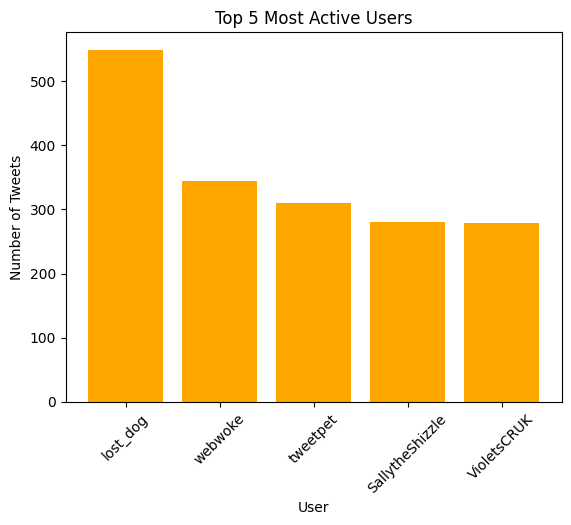

In [49]:
# Most tweeted users
top_users = df['user'].value_counts().head(5)

plt.bar(top_users.index, top_users.values, color='orange')
plt.xlabel('User')
plt.ylabel('Number of Tweets')
plt.title('Top 5 Most Active Users')
plt.xticks(rotation=45)
plt.show()

## **🧑🏻‍🏭 Data Preprocessing**
To prepare tweets for sentiment analysis, I plan to apply the following preprocessing steps in the most effective order:

* **Lowercasing:** Convert all text to lowercase to ensure uniformity.
* **Expand Contractions:** Convert contractions (e.g., "can't" → "cannot") to their full forms for clarity.
* **Remove URLs, Mentions and Emojis:** Eliminate URLs, user mentions (e.g., `@username`) and emojis to focus on the core content.
* **Tokenization:** Split the tweet into individual words or tokens.
* **Remove Stopwords:** Filter out common stopwords to reduce noise and highlight meaningful words.
* **Negation Handling:** Combine negation words with the following token (e.g., "not good" → "not\_good") to preserve sentiment.
* **Lemmatization:** Reduce words to their base or dictionary forms to unify similar terms (e.g., "running" → "run").

These steps help clean, standardize, and enrich the data for more accurate and meaningful sentiment classification.

In [50]:
# Lower all text
df['text'] = df['text'].apply(lambda text: text.lower())

In [51]:
import re

def expand_contractions(text):
    contractions = {
        r"\bthat's\b": "that is",
        r"\bit's\b": "it is",
        r"\bdon't\b": "do not",
        r"\bcan't\b": "cannot",
        r"\bwon't\b": "will not",
        r"\bisn't\b": "is not",
        r"\baren't\b": "are not",
        r"\bhasn't\b": "has not",
        r"\bhaven't\b": "have not",
        r"\bdoesn't\b": "does not",
        r"\bdidn't\b": "did not",
        r"\bshouldn't\b": "should not",
        r"\bwouldn't\b": "would not",
        r"\bcouldn't\b": "could not",
        r"\bi'm\b": "i am"
    }

    for contraction, expanded in contractions.items():
        text = re.sub(contraction, expanded, text, flags=re.IGNORECASE)
    
    return text

# Apply to your DataFrame
df['text'] = df['text'].apply(expand_contractions)

df['text'].head()

0    @switchfoot http://twitpic.com/2y1zl - awww, t...
1    is upset that he cannot update his facebook by...
2    @kenichan i dived many times for the ball. man...
3      my whole body feels itchy and like its on fire 
4    @nationwideclass no, it is not behaving at all...
Name: text, dtype: object

In [52]:
# Remove mentions from the 'text' column
df['text'] = df['text'].str.replace(r'@\w+', '', regex=True)

# Remove URLs from the 'text' column
df['text'] = df['text'].str.replace(r'http\S+|www.\S+', '', regex=True)

# Remove special characters if any (emojis, etc.)
df['text'] = df['text'].apply(lambda x: re.sub(r"[^a-zA-Z\s]", "", x))

df['text'].head()

0       awww that is a bummer  you shoulda got davi...
1    is upset that he cannot update his facebook by...
2     i dived many times for the ball managed to sa...
3      my whole body feels itchy and like its on fire 
4     no it is not behaving at all i am mad why am ...
Name: text, dtype: object

In [ ]:
import nltk
nltk.download('punkt', force=True)
nltk.download('punkt_tab', force=True)
nltk.download('stopwords', force=True)
nltk.download('wordnet', force=True)
nltk.download('omw-1.4', force=True)
nltk.download('averaged_perceptron_tagger', force=True)

from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
from nltk.corpus import wordnet
from nltk import pos_tag

# Tokenize each tweet
df['tokens'] = df['text'].apply(lambda x: word_tokenize(x))

df.head()

[nltk_data] Downloading package punkt to /Users/mertcetin/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mertcetin/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mertcetin/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mertcetin/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/mertcetin/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/mertcetin/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [ ]:
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from tokens
df['tokens'] = df['tokens'].apply(lambda tokens: [token for token in tokens if token.lower() not in stop_words])

df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mertcetin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,sentiment,user,text,tokens
0,0,_TheSpecialOne_,awww that is a bummer you shoulda got davi...,"[awww, bummer, shoulda, got, david, carr, thir..."
1,0,scotthamilton,is upset that he cannot update his facebook by...,"[upset, update, facebook, texting, might, cry,..."
2,0,mattycus,i dived many times for the ball managed to sa...,"[dived, many, times, ball, managed, save, rest..."
3,0,ElleCTF,my whole body feels itchy and like its on fire,"[whole, body, feels, itchy, like, fire]"
4,0,Karoli,no it is not behaving at all i am mad why am ...,"[behaving, mad, see]"


In [ ]:
import string

# Remove empty strings and punctuation
df['tokens'] = df['tokens'].apply(lambda tokens: [token for token in tokens if token and token not in string.punctuation])

df.head()

,sentiment,user,text,tokens
0,0,_TheSpecialOne_,awww that is a bummer you shoulda got davi...,"[awww, bummer, shoulda, got, david, carr, thir..."
1,0,scotthamilton,is upset that he cannot update his facebook by...,"[upset, update, facebook, texting, might, cry,..."
2,0,mattycus,i dived many times for the ball managed to sa...,"[dived, many, times, ball, managed, save, rest..."
3,0,ElleCTF,my whole body feels itchy and like its on fire,"[whole, body, feels, itchy, like, fire]"
4,0,Karoli,no it is not behaving at all i am mad why am ...,"[behaving, mad, see]"


In [ ]:
# Select an indexed tweet
sample_idx = 1000
original_text = df['text'].iloc[sample_idx]
tokens = df['tokens'].iloc[sample_idx]

# Print the comparison
print("Original Text:")
print(original_text)
print("\nTokenized Version:")
print(tokens)

Original Text:
  um that would be a hell no to the fugly poker dog pants on the cruise  hi jonathan sorry i missed you 

Tokenized Version:
['um', 'would', 'hell', 'fugly', 'poker', 'dog', 'pants', 'cruise', 'hi', 'jonathan', 'sorry', 'missed']


**Noticed that there are some filler words in the tokens, so it is better to remove them.**

In [ ]:
filler_words = {"um", "uh", "hmm", "lol", "haha", "yo", "hey"}
df['tokens'] = df['tokens'].apply(lambda tokens: [t for t in tokens if t not in filler_words])

sample_idx = 1000
original_text = df['text'].iloc[sample_idx]
tokens = df['tokens'].iloc[sample_idx]

# Print the comparison
print("Original Text:")
print(original_text)
print("\nTokenized Version:")
print(tokens)

Original Text:
  um that would be a hell no to the fugly poker dog pants on the cruise  hi jonathan sorry i missed you 

Tokenized Version:
['would', 'hell', 'fugly', 'poker', 'dog', 'pants', 'cruise', 'hi', 'jonathan', 'sorry', 'missed']


In [ ]:
def handle_negation(tokens):
    negations = {"not", "no", "never", "n't", "cannot", "don't", "didn't", "won't", "can't", "isn't", "aren't", "wasn't", "weren't"}
    new_tokens = []
    
    if not tokens:
        return new_tokens
    
    skip_next = False

    for i in range(len(tokens) - 1):
        if skip_next:
            skip_next = False
            continue
        if tokens[i] in negations:
            new_tokens.append(tokens[i] + "_" + tokens[i + 1])
            skip_next = True
        else:
            new_tokens.append(tokens[i])
    
    if not skip_next:
        new_tokens.append(tokens[-1])
    
    return new_tokens

df['tokens'] = df['tokens'].apply(handle_negation)

df.head()

,sentiment,user,text,tokens
0,0,_TheSpecialOne_,awww that is a bummer you shoulda got davi...,"[awww, bummer, shoulda, got, david, carr, thir..."
1,0,scotthamilton,is upset that he cannot update his facebook by...,"[upset, update, facebook, texting, might, cry,..."
2,0,mattycus,i dived many times for the ball managed to sa...,"[dived, many, times, ball, managed, save, rest..."
3,0,ElleCTF,my whole body feels itchy and like its on fire,"[whole, body, feels, itchy, like, fire]"
4,0,Karoli,no it is not behaving at all i am mad why am ...,"[behaving, mad, see]"


### 🧠 **Lemmatization**

Lemmatization reduces words to their dictionary form (e.g., `"running"` → `"run"`, `"better"` → `"good"`), improving consistency and reducing sparsity.

In this project, we use WordNetLemmatizer lemmatization with NLTK for more accurate results.

This helps the model treat different forms of the same word as one.

In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

df['tokens'] = df['tokens'].apply(lemmatize_tokens)

df.head()

,sentiment,user,text,tokens
0,0,_TheSpecialOne_,awww that is a bummer you shoulda got davi...,"[awww, bummer, shoulda, got, david, carr, thir..."
1,0,scotthamilton,is upset that he cannot update his facebook by...,"[upset, update, facebook, texting, might, cry,..."
2,0,mattycus,i dived many times for the ball managed to sa...,"[dived, many, time, ball, managed, save, rest,..."
3,0,ElleCTF,my whole body feels itchy and like its on fire,"[whole, body, feel, itchy, like, fire]"
4,0,Karoli,no it is not behaving at all i am mad why am ...,"[behaving, mad, see]"


**I have observed that some of the tweets are just meaingless words and numbers. And they are not useful for training the model. So I will remove them.**

In [ ]:
print("Original:", df.loc[981534, 'text'])
print("Tokens:", df.loc[981534, 'tokens']) # empty

Original:  do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it 
Tokens: []


In [ ]:
# Calculate the number of tweets with empty tokens
empty_count = df['tokens'].apply(lambda tokens: len(tokens) == 0).sum()
print(f"Number of tweets with empty tokens: {empty_count}")

# Filter out tweets with empty tokens
df = df[df['tokens'].apply(lambda tokens: len(tokens) > 0)]

Number of tweets with empty tokens: 9066


In [ ]:
top_n = 10
longest_tweets = df['text'].str.split().str.len().nlargest(top_n).index

original_counts = []
preprocessed_counts = []
labels = []

for idx in longest_tweets:
    original = df.loc[idx, 'text']
    tokens = df.loc[idx, 'tokens']
    
    original_counts.append(len(original.split()))
    preprocessed_counts.append(len(tokens))
    labels.append(f"Tweet {idx}")

### **📊 Token Count Before and After Preprocessing**
The bar chart below compares the number of tokens in selected long tweets before and after preprocessing.  
Preprocessing steps include **tokenization, stopword removal, contraction expansion, negation handling**, and **lemmatization**.

As shown, the number of tokens is significantly reduced across all samples, indicating that irrelevant or redundant information (such as filler words, duplicates, and informal constructs) was effectively removed.

This transformation helps focus the sentiment analysis model on the core meaningful content of each tweet.

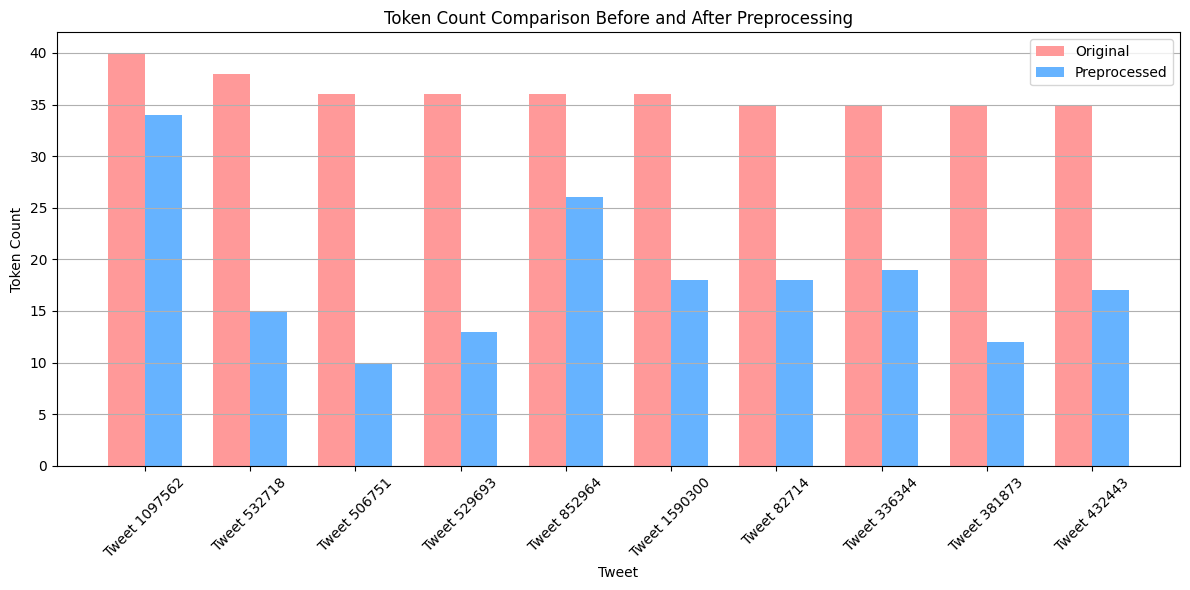

In [ ]:
import numpy as np

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, original_counts, width, label='Original', color='#ff9999')
plt.bar(x + width/2, preprocessed_counts, width, label='Preprocessed', color='#66b3ff')

plt.xlabel("Tweet")
plt.ylabel("Token Count")
plt.title("Token Count Comparison Before and After Preprocessing")
plt.xticks(x, labels, rotation=45)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### **🎨 WordCloud: Before vs After Preprocessing**

Below is a visual comparison of a tweet before and after preprocessing.  
Stopwords and noise such as `"gotta"`, `"ta"` are removed, revealing key emotional words like `"tired"`, `"mad"`, and `"work"`.

This highlights the effectiveness of preprocessing in cleaning and clarifying tweet content for sentiment analysis.

In [ ]:
%pip install wordcloud --quiet

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


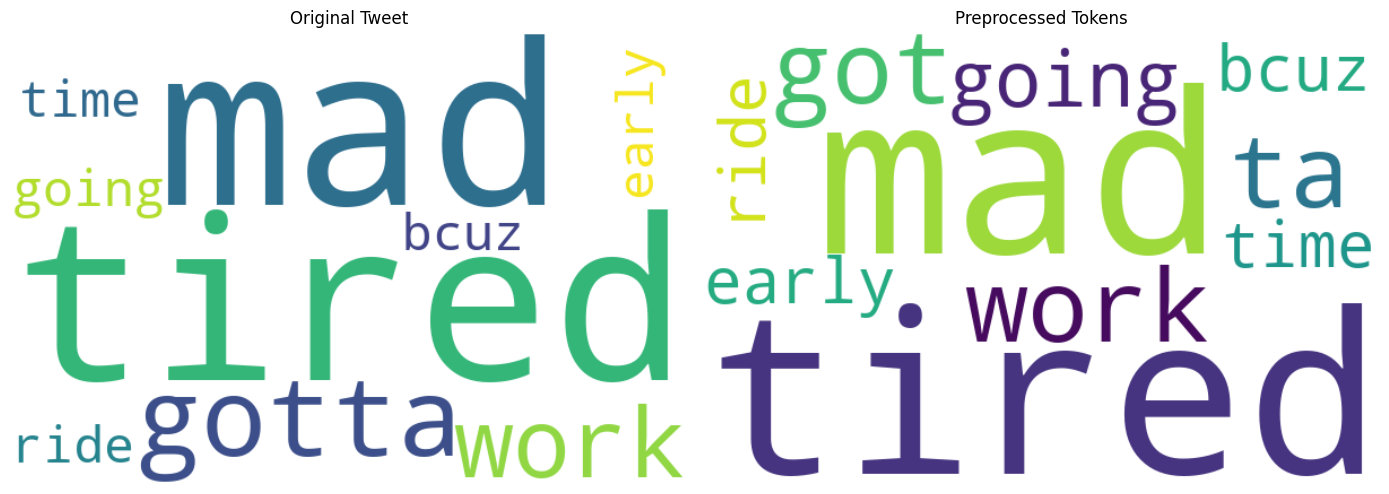

In [ ]:
sample_index = 506751 # change if needed

from wordcloud import WordCloud
import matplotlib.pyplot as plt

original_text = df.loc[sample_index, 'text']
cleaned_text = ' '.join(df.loc[sample_index, 'tokens'])

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Original
wordcloud_original = WordCloud(width=600, height=400, background_color='white').generate(original_text)
axs[0].imshow(wordcloud_original, interpolation='bilinear')
axs[0].axis('off')
axs[0].set_title('Original Tweet')

# Preprocessed
wordcloud_cleaned = WordCloud(width=600, height=400, background_color='white', colormap='viridis').generate(cleaned_text)
axs[1].imshow(wordcloud_cleaned, interpolation='bilinear')
axs[1].axis('off')
axs[1].set_title('Preprocessed Tokens')

plt.tight_layout()
plt.show()

> ### **🧩 Additional Preprocessing Ideas**
> While the current preprocessing pipeline is sufficient for sentiment analysis, the following optional enhancements could be explored to further improve model performance or handle edge cases:
>
> - **Punctuation Removal:** Removing unnecessary punctuation (e.g., `, . ! ?`) to reduce noise. Be cautious, as some punctuation can carry sentiment.
> - **Spelling Correction:** Fixing misspelled words (e.g., `"goood"` → `"good"`) using libraries like `TextBlob` or `SymSpell`.
> - **Slang & Abbreviation Normalization:** Converting informal phrases (e.g., `"gonna"` → `"going to"`, `"idk"` → `"I don't know"`) using a custom slang dictionary.
> - **Emoji Sentiment Mapping:** Instead of removing emojis, they can be mapped to words representing sentiment (e.g., 😊 → "happy", 😢 → "sad") using emoji libraries.
> - **Hashtag Segmentation:** Breaking compound hashtags into separate words (e.g., `#MondayBlues` → `monday blues`) to preserve context.
> - **Character Elongation Handling:** Normalizing words like `"soooo"` to `"so"` by limiting repeated characters.

> These techniques are optional and often task-dependent. For large datasets like Sentiment140, the current pipeline offers a strong balance between efficiency and effectiveness.

### **🧹 Label Simplification for Binary Classification**
The original Sentiment140 dataset includes sentiment labels:  
- `0` → Negative  
- `2` → Neutral  
- `4` → Positive  

However, the dataset contains **no actual examples with label `2` (Neutral)**.  

To simplify the task and avoid imbalance or confusion, I have reduced the problem to **binary classification**:

- `0` → Negative  
- `1` → Positive (converted from 4)

In [ ]:
df = df[df['sentiment'].isin([0, 4])]
df['sentiment'] = df['sentiment'].map({0: 0, 4: 1})

### **🧮 TF-IDF (Term Frequency – Inverse Document Frequency)**
To convert textual data into numerical form suitable for machine learning models, I apply the **TF-IDF** technique.  

TF-IDF assigns a weight to each word based on:

- **Term Frequency (TF):** How frequently the word appears in a specific tweet.
- **Inverse Document Frequency (IDF):** How rare the word is across all tweets in the dataset.

This helps the model:
- Emphasize **important and unique words** in each tweet
- De-emphasize **common, less informative words** (e.g., “the”, “is”, “and”)

In this project, I used `TfidfVectorizer` from `scikit-learn` to transform preprocessed tweets into numerical vectors before training the classifier.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['tokens'].apply(lambda tokens: ' '.join(tokens))
y = df['sentiment']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

### **Multinomial Naive Bayes**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

### **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, target_names=["Negative", "Positive"]))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))